Exploring and modelling the CIFAR dataset over here.. let's see how it goes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import cifar10

train, test= cifar10.load_data()

In [3]:
train[0].shape, train[1].shape

((50000, 32, 32, 3), (50000, 1))

As mentioned by the author in the documentation for CIFAR 10..

Each of the batch files contains a dictionary with the following elements:    
**data** -- a 10000x3072 numpy array of uint8s. Each row of the array stores a 32x32 colour image. The first 1024 entries contain the red channel values, the next 1024 the green, and the final 1024 the blue. The image is stored in row-major order, so that the first 32 entries of the array are the red channel values of the first row of the image.   
**labels** -- a list of 10000 numbers in the range 0-9. The number at index i indicates the label of the ith image in the array data.

First and foremost, we seperate our train, validation and test sets

In [4]:
X_train, y_train = train[0][:40000], train[1][:40000]
X_valid, y_valid = train[0][40000:], train[1][40000:]
X_test, y_test= test[0], test[1]

In [5]:
X_train.shape

(40000, 32, 32, 3)

In [6]:
X_valid.shape

(10000, 32, 32, 3)

In [7]:
X_test.shape

(10000, 32, 32, 3)

Perhaps, we might be giving away a little too much data away for validation, but let's see where it goes

In [8]:
X_train[0].shape ## this is the shape of one image

(32, 32, 3)

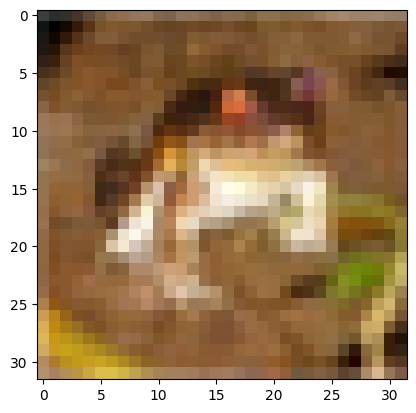

In [9]:
plt.imshow(X_train[0])

Even for a human, this sort of a pixelated image is tough to identify

In [10]:
# This list has been given to us in the documentation for reference
labels = np.array([
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
])

Let's see what it is

In [11]:
y_train[0]

array([6], dtype=uint8)

In [12]:
labels[y_train[0]]

array(['frog'], dtype='<U10')

Well... that was a frog.. but are all pictures going to be like this?

In [13]:
labels[y_train[0]][0]

'frog'

In [14]:
#Scaling the 0-255 values down to 0-1

X_train, X_valid, X_test= X_train/255, X_valid/255, X_test/255

In [15]:
X_train[0][:,1][:5]

array([[0.16862745, 0.18039216, 0.17647059],
       [0.        , 0.        , 0.        ],
       [0.0627451 , 0.02745098, 0.        ],
       [0.14901961, 0.07843137, 0.01568627],
       [0.23137255, 0.1254902 , 0.04313725]])

In [16]:
indices= np.random.choice(40000, 40, replace= False)
indices

array([21033,  9352, 37625, 34012, 17401, 26015, 28015,  4447, 28970,
       21095, 29633,  9240, 27382, 17814, 20876,  1208,  2820, 38123,
       13770, 23837,  4892, 16842, 31578,  1985, 11859,  7068, 31333,
       24183, 33148,  2129, 22635, 32938, 10974, 17801, 12266, 28207,
       10394,  4145, 10121, 33811])

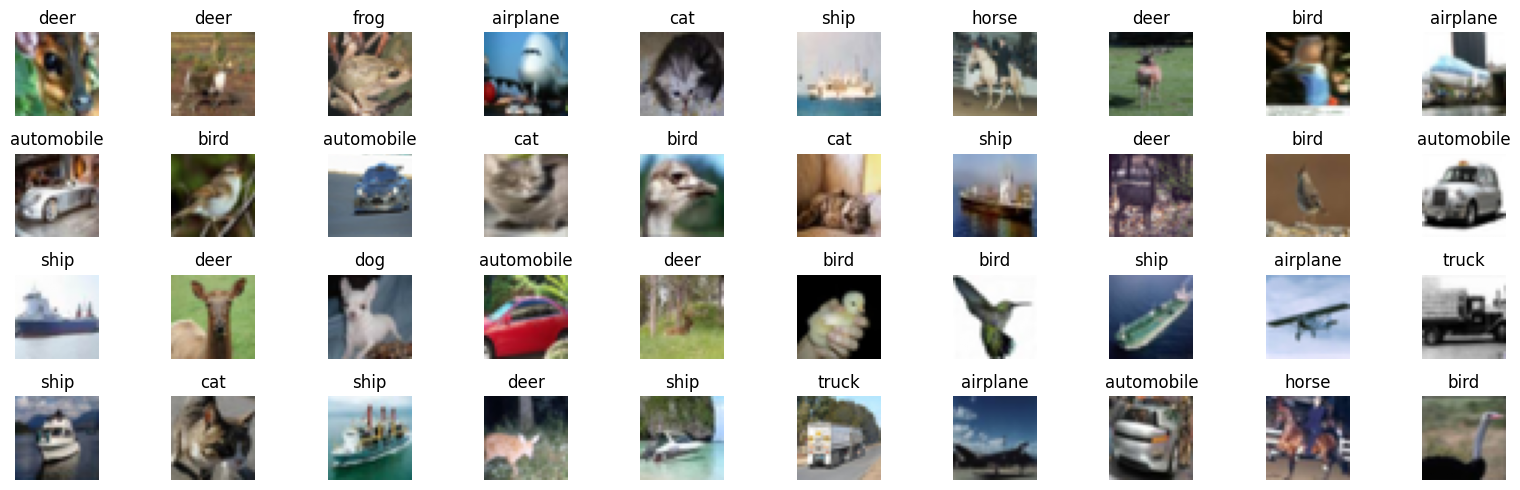

In [17]:
fig, axes= plt.subplots(4,10, figsize= (16,5))

for (i, ax) in zip(indices, axes.ravel()):
    ax.imshow(X_train[i])
    ax.set_title(labels[y_train[i]][0])
    ax.axis("off")

plt.tight_layout()

Okay, so not all, but definitely some are tough to identify

Looking, at the documentation,   
"You can find some baseline replicable results on this dataset on the project page for cuda-convnet. These results were obtained with a convolutional neural network. Briefly, they are 18% test error without data augmentation and 11% with." 

So if with a CNN, were reaching 18%... let's put a target of 20 with NN first. 

In [18]:
# We're going to import our default base model that we decided upon, it includes some Dropout in the early layers for regularization
# model3= tf.keras.Sequential([ ## With Dropout
#     tf.keras.layers.Flatten(input_shape= [32,32, 3]),
#     tf.keras.layers.Dropout(rate= 0.05), 
#     tf.keras.layers.Dense(300, activation= "relu", kernel_initializer="he_normal"), 
#     tf.keras.layers.Dropout(rate= 0.05), 
#     tf.keras.layers.Dense(150, activation= "relu", kernel_initializer="he_normal"), 
#     tf.keras.layers.Dropout(rate= 0.03), 
#     tf.keras.layers.Dense(80, activation= "relu", kernel_initializer="he_normal"), 
#     tf.keras.layers.Dropout(rate= 0.02), 
#     tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
#     tf.keras.layers.Dense(40, activation= "relu", kernel_initializer="he_normal"), 
#     tf.keras.layers.Dense(20, activation= "relu", kernel_initializer="he_normal"),
#     tf.keras.layers.Dense(10, activation= "softmax"), 
# ])

In [19]:
from tensorflow.keras.models import load_model

model = load_model("cifar_dafault_model.keras")

## Error Analysis

In [20]:
y_valid

array([[1],
       [8],
       [5],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [21]:
y_valid_pred= model.predict(X_valid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [22]:
y_valid_pred = np.argmax(y_valid_pred, axis=1)

In [23]:
y_valid_pred

array([1, 8, 5, ..., 9, 1, 7], dtype=int64)

In [24]:
labels

array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
       'horse', 'ship', 'truck'], dtype='<U10')

y_valid = y_valid.reshape(-1)

<Figure size 640x480 with 0 Axes>

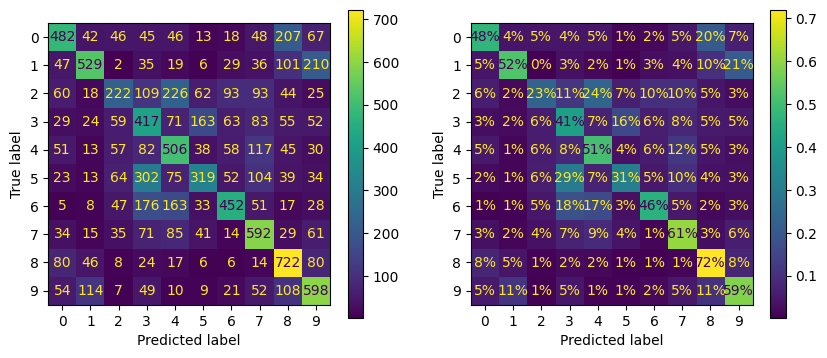

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.clf()
fig, axes= plt.subplots(1,2, figsize = (10,4))

ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, normalize= "true", values_format=".0%", ax= axes[1])
plt.show()

That gives us a good idea of our predictions, but we want to foccus on where our model is making mistakes

ValueError: row, column, and data arrays must be 1-D

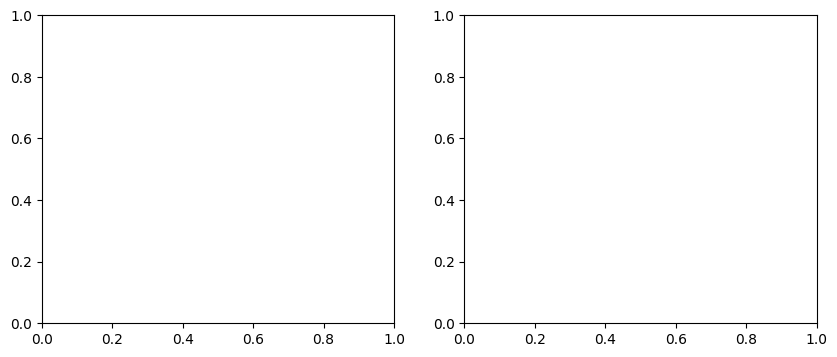

In [27]:
fig, axes= plt.subplots(1,2, figsize = (10,4))
sample_weight = (y_valid_pred != y_valid)

# x% of 'true's were misclassified as 'pred'
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[0], sample_weight=sample_weight) 
# y% of misclassified 'pred' were 'trues'
ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax= axes[1], sample_weight=sample_weight,normalize= "true", values_format=".0%")

**Observations:**

1) 39% of 0 errors as 8s
2) 43% of 1 errors as 9s
3) 43% of 5 errors as 3s
4) But 302 5s as 3's are a clear sign that this is the biggest problem..
5) Only 23% of 2's are actually being predicted.. it's errors are diverse
6) Only 31% of 5's are being able to be predicted


So 2, 3 and 5 are standing out a little bit

On further observation.. I feel it's 3 which is the biggest issue.. Working on 3 vs non 3 should give back the best returns

In [ ]:
labels

So.. we're going build a cat vs non cat classifier for now and then integrate that model into this